### Cluster analysis with K-means

In [1]:
import sys
sys.path.append("..")
from src import *
import numpy as np
np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

In [2]:
params = ParametresGenerals(
    dimensio=2,
    t_span=(0, 4*np.pi),
    t_steps=300,
    x_min=-2,
    x_max=2,
    y_min=-1,
    y_max=1,
    espai_entre_punts=0.04,
    max_clusters=50,
    num_radis=50
    )

In [3]:
condicions_inicials = generar_condicions_inicials(params)
num_trajectories = len(condicions_inicials)

In [4]:
trajectories = generar_trajectories(edo_duffing_no_autonom, condicions_inicials, params)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (5151, 300, 2)


In [5]:
# grafica_trajectories(trajectories, subfolder="no_autonom")

In [6]:
matriu_pesos = calcula_matriu_pesos(trajectories)

In [7]:
pes_max = np.max(matriu_pesos)
print(f"Pes màxim a la matriu de pesos: {pes_max:.3f}")
constant_diagonal = pes_max * 1e7

Pes màxim a la matriu de pesos: 159.460


##### Opció A: Usem el mateix radi d'esparsificació que Irina, és a dir, r = 1.0

In [8]:
radi_esparsificacio = 1.0
matriu_similaritat_W, sparsification_percent = sparcify_with_tol(matriu_pesos, tol=radi_esparsificacio)
print(f"S'ha obtingut una esparsificació del "
      f"{sparsification_percent*100:.0f}% usant una tolerància de "
      f"{radi_esparsificacio:.3f}")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)
print(matriu_similaritat_W)

S'ha obtingut una esparsificació del 85% usant una tolerància de 1.000
[[1.595e+09 2.355e+00 1.122e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.355e+00 1.595e+09 1.692e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [1.122e+00 1.692e+00 1.595e+09 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 1.595e+09 4.838e+00 2.580e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 4.838e+00 1.595e+09 5.437e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 2.580e+00 5.437e+00 1.595e+09]]


Descomposició espectral: $Lu =\lambda Du$, on la matriu diagonal de graus $D$ és $D_{ii}=\sum _{j=0}^{n} w_{ij}$.

In [9]:
vaps, veps = calcula_vaps(matriu_similaritat_W, params.max_clusters)
print("veps.shape =", veps.shape)

veps.shape = (5151, 50)


In [10]:
print(len(vaps),"vaps=",np.array2string(vaps,formatter={'float_kind':lambda x:f'{x:.1e}'}))

50 vaps= [-6.6e-19 2.9e-09 7.7e-09 8.3e-09 1.1e-08 1.2e-08 1.6e-08 1.8e-08 2.3e-08
 2.9e-08 3.0e-08 3.4e-08 3.5e-08 3.8e-08 4.0e-08 4.0e-08 4.1e-08 4.6e-08
 4.9e-08 5.0e-08 5.1e-08 5.2e-08 5.2e-08 5.5e-08 5.6e-08 5.9e-08 5.9e-08
 6.1e-08 6.4e-08 6.5e-08 6.6e-08 6.7e-08 6.8e-08 7.0e-08 7.0e-08 7.1e-08
 7.1e-08 7.1e-08 7.2e-08 7.2e-08 7.3e-08 7.4e-08 7.5e-08 7.6e-08 7.7e-08
 7.7e-08 7.8e-08 7.9e-08 7.9e-08 8.1e-08]


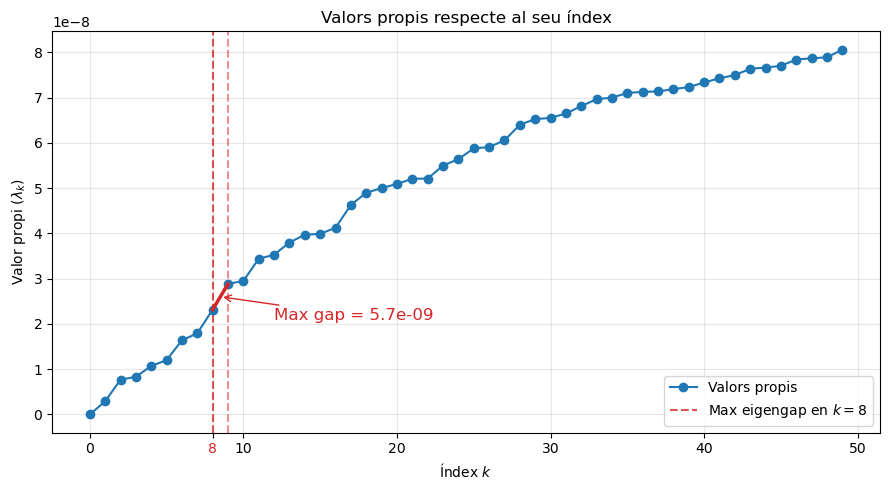

In [11]:
grafica_eigenvalues_vs_index(vaps, subfolder="no_autonom")

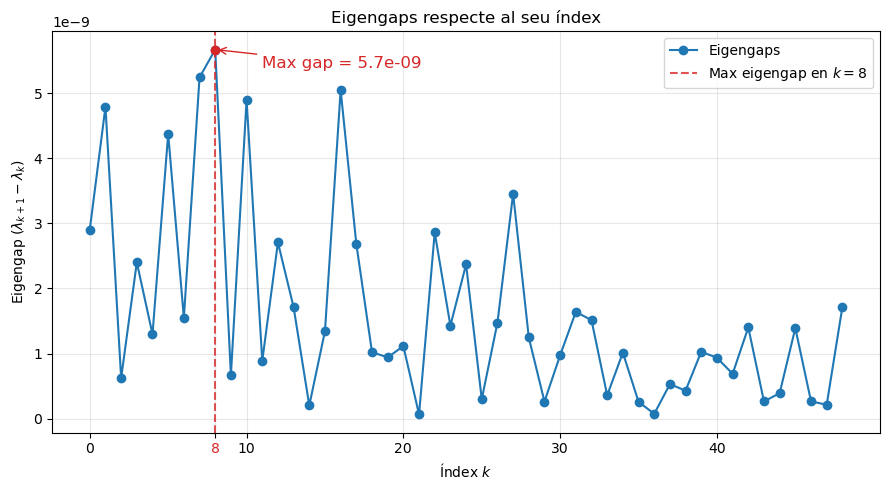

In [12]:
grafica_eigengaps_vs_index(vaps, subfolder="no_autonom")

In [13]:
num_clusters, diff_max = calcula_num_clusters_i_max_eigengap(vaps)

In [14]:
labels = troba_clusters(num_clusters, veps)

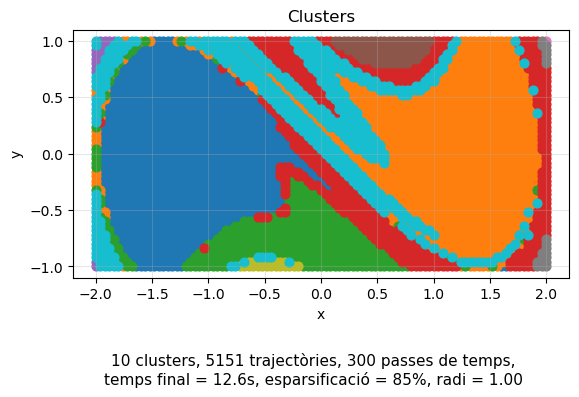

In [15]:
grafica_clusters(condicions_inicials, labels, num_clusters, radi_esparsificacio, 
                 sparsification_percent, params, subfolder="no_autonom")

##### Opció B: triar radi d'esparsificació que maximitza la diferència màxima entre VAPs consecutius

Iniciant l'escombrat de paràmetres...
Radi òptim trobat: r=3.000 | k=1 clústers | W is 0.51% sparsified


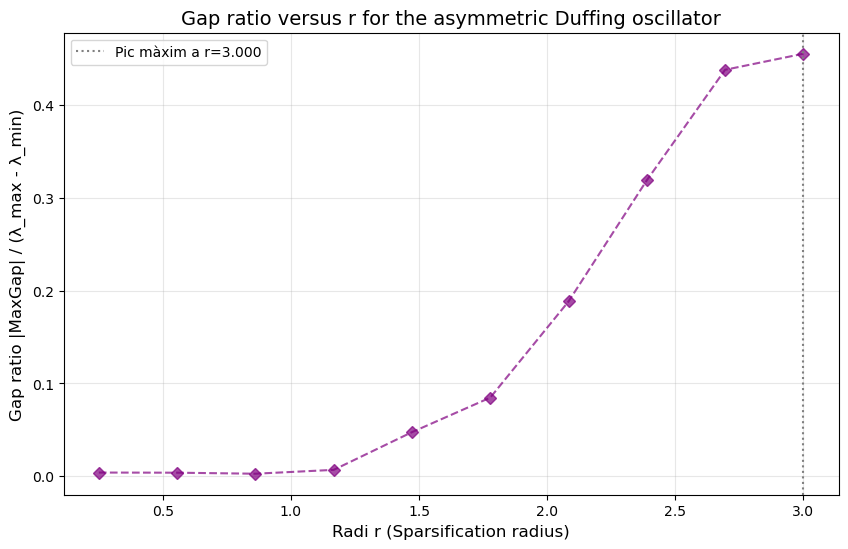

In [16]:
optimal_r, optimal_k, sparsification_percent = troba_radi_optim(trajectories)

In [17]:
labels = aplica_spectral_clustering_optim(trajectories, optimal_r, optimal_k)

Aplicant K-Means demanant exactament 1 clústers...


In [18]:
# grafica_clusters(condicions_inicials, labels, optimal_k, optimal_r, 
#                  sparsification_percent, params,subfolder="no_autonom")